# Model Comparison: Random Forest vs. XGBoost (Validation Set)
FraudBusters — INFO 442 Group 1 — Aylin

**Split usage (final, confirmed with the team):**
- Validation set → used for hyperparameter tuning AND for this model comparison / selection stage
- Test set → reserved for the ONE-TIME final evaluation, after RF vs. XGBoost is decided (Emma's Week 9 step)

**Hyperparameters used (both final, from teammates' Optuna studies):**
- Random Forest: Katie's final tuned params (best accuracy: 0.9395)
- XGBoost: Elizabeth's final tuned params (best ROC-AUC: 0.9354)


## 1. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
from scipy.stats import spearmanr
import xgboost as xgb

sns.set(style="whitegrid")
%matplotlib inline

# Update this to wherever your files actually live
DATA_DIR = r"C:\Users\aylin\OneDrive\Desktop\INFO\INFO442\Project"

## 2. Load data (train for fitting, VALIDATION set for model comparison)

In [5]:
X_train = pd.read_csv(DATA_DIR + r"\train_transaction.csv")
X_val = pd.read_csv(DATA_DIR + r"\val_transaction.csv")

y_train = X_train['isFraud']
X_train = X_train.drop(columns=['isFraud'])

y_val = X_val['isFraud']
X_val = X_val.drop(columns=['isFraud'])

for df in [X_train, X_val]:
    drop_cols = [c for c in ['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0'] if c in df.columns]
    df.drop(columns=drop_cols, inplace=True)

X_train = X_train[X_train.columns.drop(list(X_train.filter(regex='email')))]
X_val = X_val[X_val.columns.drop(list(X_val.filter(regex='email')))]

# Safety check: one-hot encode any remaining text/category columns.
# RandomForestClassifier requires fully numeric input (unlike XGBoost's native
# DMatrix with enable_categorical=True, which can handle raw category strings).
# This makes the notebook work regardless of whether the source CSV was already encoded.
obj_cols = X_train.select_dtypes(include='object').columns.tolist()
print("Text/category columns found, one-hot encoding:", obj_cols)

X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)

# Align val columns to match train exactly (handles any category present in one
# split but not the other)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Fraud % in train:", y_train.mean() * 100)
print("Fraud % in val:", y_val.mean() * 100)

Text/category columns found, one-hot encoding: ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
Train shape: (590540, 399)
Val shape: (49071, 399)
Fraud % in train: 3.4990009144173126
Fraud % in val: 3.386929143485969


## 3. Random Forest

**⚠️ PLACEHOLDER hyperparameters below.** Katie's Optuna tuning is still in progress.
The moment she sends her `study.best_params`, replace the dictionary in `rf_params` with
her actual values — everything else in this notebook stays the same.

In [7]:
# Katie's FINAL tuned Random Forest hyperparameters (best accuracy: 0.9395)
rf_params = {
    'n_estimators': 195,
    'max_depth': 48,
    'min_samples_split': 10,
    'min_samples_leaf': 2,
    'min_weight_fraction_leaf': 0.0,
    'max_samples': 1.0,
    'random_state': 42,
    'n_jobs': -1
}

rf_model = RandomForestClassifier(**rf_params, oob_score=True)
rf_model.fit(X_train, y_train)

print("Out-of-Bag Score (accuracy):", rf_model.oob_score_)

y_proba_rf = rf_model.predict_proba(X_val)[:, 1]

Out-of-Bag Score (accuracy): 0.9786737562231178


## 4. XGBoost — Elizabeth's tuned hyperparameters (locked in, from her Optuna study)

In [9]:
train_data = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
val_data = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)

# Elizabeth's best params from her Optuna study (250 trials, best ROC-AUC: 0.9354)
xgb_params = {
    'max_leaves': 374,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'max_depth': 13,
    'eta': 0.3727634685843487,
    'gamma': 0.00014121726480517213,
    'tree_method': 'hist',
    'subsample': 0.9798380685518304,
    'colsample_bytree': 0.6511299034135586,
    'seed': 11,
    'eval_metric': 'auc',
    'verbosity': 0,
    'reg_alpha': 0.006078931276328701,
    'reg_lambda': 9.641597078203631,
    'grow_policy': 'lossguide'
}

result_xgb = xgb.train(
    xgb_params,
    train_data,
    num_boost_round=100,
    evals=[(train_data, 'train'), (val_data, 'valid')],
    verbose_eval=10
)

y_proba_xgb = result_xgb.predict(val_data)

[0]	train-auc:0.87842	valid-auc:0.79876
[10]	train-auc:0.95113	valid-auc:0.84345
[20]	train-auc:0.96767	valid-auc:0.81163
[30]	train-auc:0.97722	valid-auc:0.81804
[40]	train-auc:0.98186	valid-auc:0.83288
[50]	train-auc:0.98602	valid-auc:0.83579
[60]	train-auc:0.98917	valid-auc:0.83010
[70]	train-auc:0.99172	valid-auc:0.83131
[80]	train-auc:0.99304	valid-auc:0.83562
[90]	train-auc:0.99429	valid-auc:0.82951
[99]	train-auc:0.99527	valid-auc:0.82068


## 5. Evaluation functions

In [11]:
def evaluate_model(y_true, y_proba, model_name="model"):
    roc_auc = roc_auc_score(y_true, y_proba)
    avg_precision = average_precision_score(y_true, y_proba)
    f1_default = f1_score(y_true, (y_proba >= 0.5).astype(int))

    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

    return {
        "model": model_name,
        "roc_auc": roc_auc,
        "average_precision": avg_precision,
        "f1_default_threshold": f1_default,
        "best_threshold": best_threshold,
        "f1_tuned_threshold": f1_scores[best_idx],
    }


def compare_models(results_list):
    df = pd.DataFrame(results_list)
    print(df.round(4))

    metric_cols = ["roc_auc", "average_precision", "f1_default_threshold", "f1_tuned_threshold"]
    df.set_index("model")[metric_cols].plot(kind="bar", figsize=(10, 6))
    plt.title("Model Comparison: Random Forest vs. XGBoost (Validation Set)")
    plt.ylabel("Score")
    plt.xticks(rotation=0)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    return df

## 6. Run the comparison

           model  roc_auc  average_precision  f1_default_threshold  \
0  Random Forest   0.8872             0.4975                0.0618   
1        XGBoost   0.8207             0.3328                0.1572   

   best_threshold  f1_tuned_threshold  
0          0.2083              0.4805  
1          0.0136              0.3520  


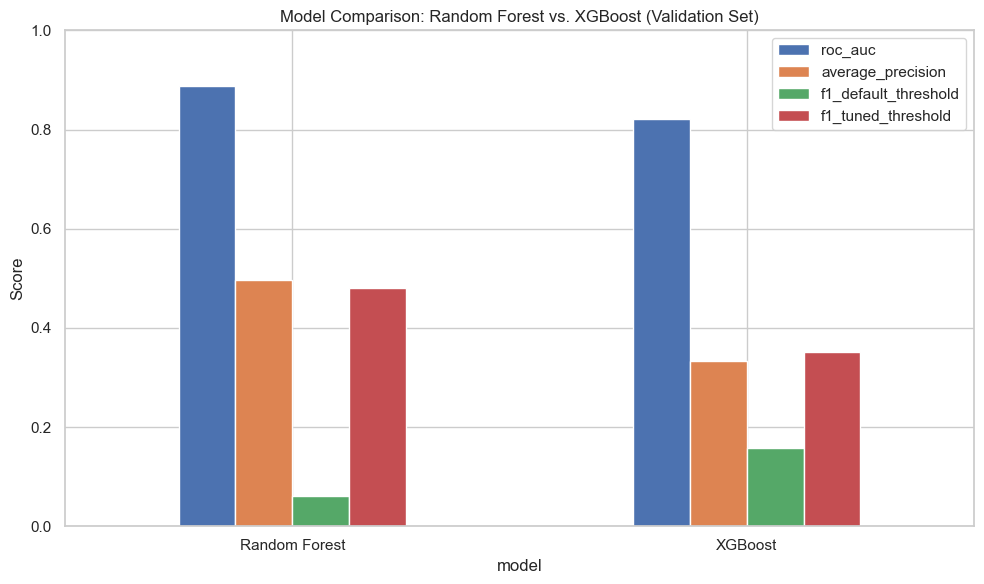

In [13]:
results = [
    evaluate_model(y_val, y_proba_rf, model_name="Random Forest"),
    evaluate_model(y_val, y_proba_xgb, model_name="XGBoost"),
]
comparison_df = compare_models(results)

## 7. ROC and Precision-Recall curves

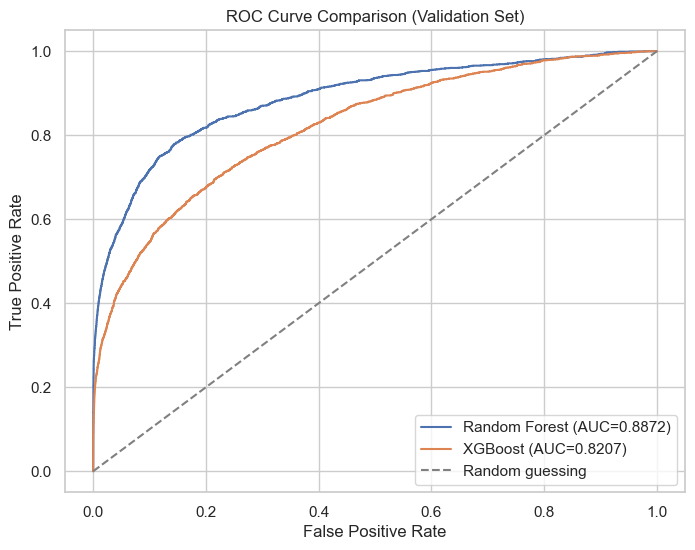

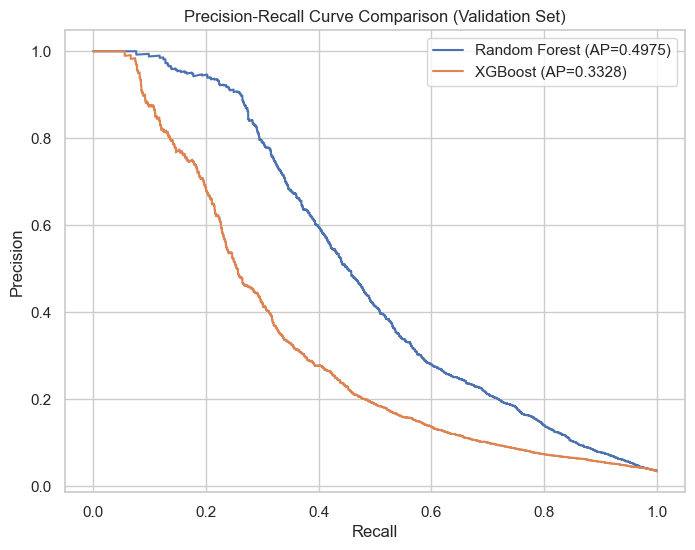

In [15]:
def plot_roc_overlay(models_dict, y_true):
    plt.figure(figsize=(8, 6))
    for name, y_proba in models_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc = roc_auc_score(y_true, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Random guessing")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison (Validation Set)")
    plt.legend()
    plt.show()


def plot_pr_overlay(models_dict, y_true):
    plt.figure(figsize=(8, 6))
    for name, y_proba in models_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        ap = average_precision_score(y_true, y_proba)
        plt.plot(recall, precision, label=f"{name} (AP={ap:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve Comparison (Validation Set)")
    plt.legend()
    plt.show()


plot_roc_overlay({"Random Forest": y_proba_rf, "XGBoost": y_proba_xgb}, y_val)
plot_pr_overlay({"Random Forest": y_proba_rf, "XGBoost": y_proba_xgb}, y_val)

## 8. Confusion matrices at each model's tuned threshold

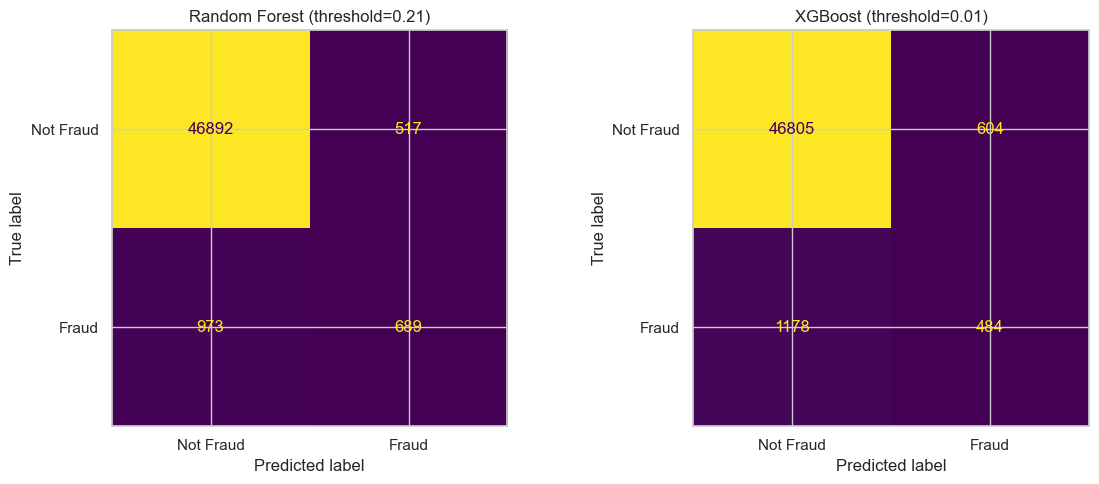

In [17]:
thresholds = {r["model"]: r["best_threshold"] for r in results}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_proba) in zip(axes, {"Random Forest": y_proba_rf, "XGBoost": y_proba_xgb}.items()):
    thresh = thresholds[name]
    y_pred = (y_proba >= thresh).astype(int)
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Fraud", "Fraud"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{name} (threshold={thresh:.2f})")
plt.tight_layout()
plt.show()

## 9. Feature importance comparison

In [19]:
imp_rf = pd.DataFrame({
    "feature": X_train.columns,
    "rf_importance": rf_model.feature_importances_
})
imp_rf["rf_importance_norm"] = imp_rf["rf_importance"] / imp_rf["rf_importance"].sum()

xgb_score_dict = result_xgb.get_score(importance_type="gain")
imp_xgb = pd.DataFrame({
    "feature": X_train.columns,
    "xgb_importance": [xgb_score_dict.get(f, 0.0) for f in X_train.columns]
})
imp_xgb["xgb_importance_norm"] = imp_xgb["xgb_importance"] / imp_xgb["xgb_importance"].sum()

imp = imp_rf.merge(imp_xgb, on="feature", how="outer").fillna(0)
imp["rf_rank"] = imp["rf_importance_norm"].rank(ascending=False, method="min")
imp["xgb_rank"] = imp["xgb_importance_norm"].rank(ascending=False, method="min")
imp["rank_diff"] = (imp["rf_rank"] - imp["xgb_rank"]).abs()

corr, pval = spearmanr(imp["rf_importance_norm"], imp["xgb_importance_norm"])
print(f"Spearman rank correlation between RF and XGBoost importances: {corr:.3f} (p={pval:.3g})")

imp["combined"] = imp["rf_importance_norm"] + imp["xgb_importance_norm"]
top20 = imp.sort_values("combined", ascending=False).head(20)
print("\nTop 20 features by combined importance:")
print(top20[["feature", "rf_importance_norm", "xgb_importance_norm", "rank_diff"]])

print("\nFeatures either model ranks in its top 20, but they disagree on most:")
top_by_either = imp[(imp["rf_rank"] <= 20) | (imp["xgb_rank"] <= 20)]
print(top_by_either.sort_values("rank_diff", ascending=False)[
    ["feature", "rf_rank", "xgb_rank", "rank_diff"]
].head(15))

Spearman rank correlation between RF and XGBoost importances: 0.350 (p=5.89e-13)

Top 20 features by combined importance:
            feature  rf_importance_norm  xgb_importance_norm  rank_diff
222            V258            0.016263             0.281604        7.0
42      ProductCD_W            0.000133             0.189860      376.0
11               C7            0.010461             0.049821       17.0
0                C1            0.022516             0.011554        8.0
216            V252            0.000508             0.029385      325.0
127            V172            0.001181             0.022147      203.0
5               C14            0.015740             0.006647        3.0
160            V201            0.011251             0.011042        6.0
4               C13            0.019580             0.002085       34.0
296            V324            0.001118             0.019334      209.0
44    TransactionDT            0.018292             0.000948      126.0
45    Transact

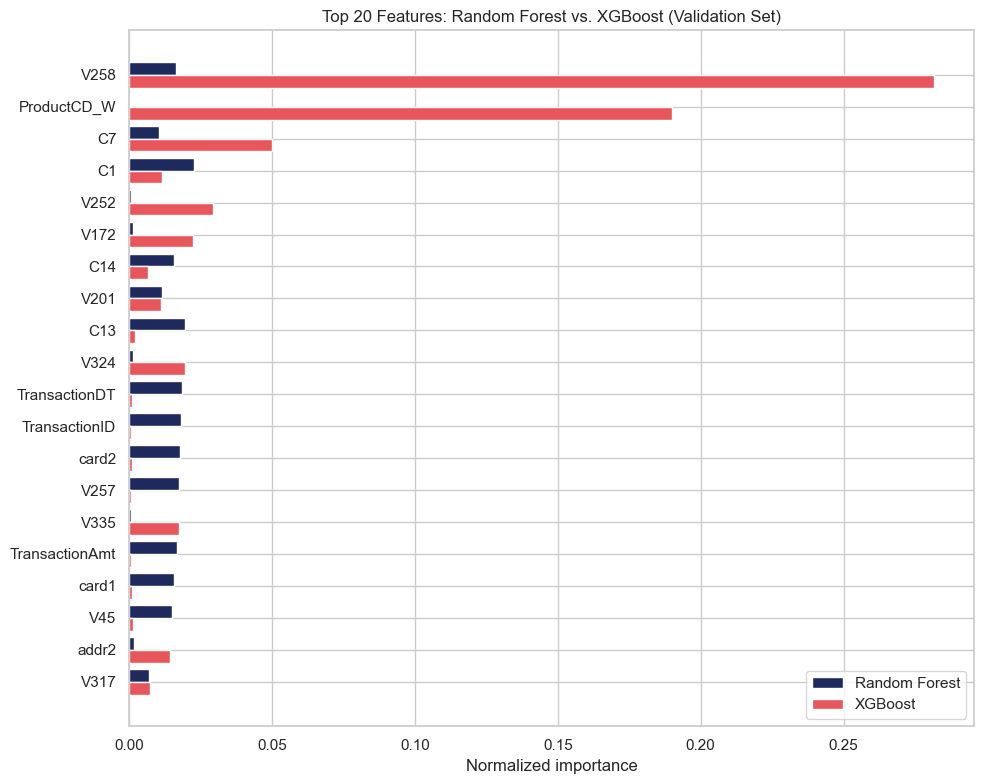

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(top20))
ax.barh(y_pos - 0.2, top20["rf_importance_norm"], height=0.4, label="Random Forest", color="#1E2A5E")
ax.barh(y_pos + 0.2, top20["xgb_importance_norm"], height=0.4, label="XGBoost", color="#E8555A")
ax.set_yticks(y_pos)
ax.set_yticklabels(top20["feature"])
ax.invert_yaxis()
ax.set_xlabel("Normalized importance")
ax.set_title("Top 20 Features: Random Forest vs. XGBoost (Validation Set)")
ax.legend()
plt.tight_layout()
plt.show()